In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the saved backtest outputs
equity = pd.read_csv("../data/backtest_ndsn_otis_equity.csv", index_col=0, parse_dates=True).squeeze()
trades = pd.read_csv("../data/backtest_ndsn_otis_trades.csv", parse_dates=["timestamp"])

# Also load the underlying prices for context
from src.data.storage import get_connection, load_prices
conn = get_connection("../data/market.duckdb")
long_df = load_prices(conn, tickers=["NDSN", "OTIS"], start="2015-01-01")
long_df["date"] = pd.to_datetime(long_df["date"])
conn.close()
wide = long_df.pivot(index="date", columns="ticker", values="adj_close")

print(f"Equity points: {len(equity)}")
print(f"Trades: {len(trades)}")
print(f"Date range: {equity.index.min().date()} to {equity.index.max().date()}")
equity.head()

Equity points: 1204
Trades: 45
Date range: 2020-03-19 to 2024-12-30


2020-03-19    100000.0
2020-03-20    100000.0
2020-03-23    100000.0
2020-03-24    100000.0
2020-03-25    100000.0
Name: equity, dtype: float64

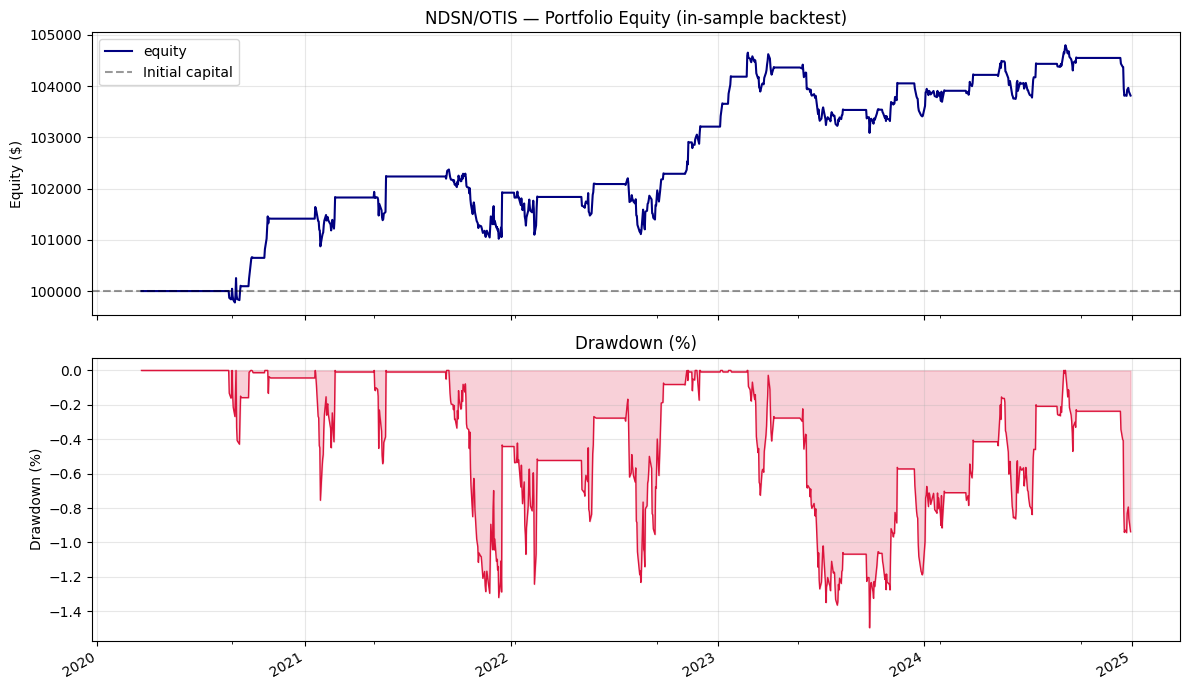

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Equity curve
equity.plot(ax=axes[0], color="navy", linewidth=1.5)
axes[0].axhline(100_000, color="black", linestyle="--", alpha=0.4, label="Initial capital")
axes[0].set_title("NDSN/OTIS — Portfolio Equity (in-sample backtest)")
axes[0].set_ylabel("Equity ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Drawdown
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max * 100  # in percent
drawdown.plot(ax=axes[1], color="crimson", linewidth=1.0)
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="crimson", alpha=0.2)
axes[1].set_title("Drawdown (%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

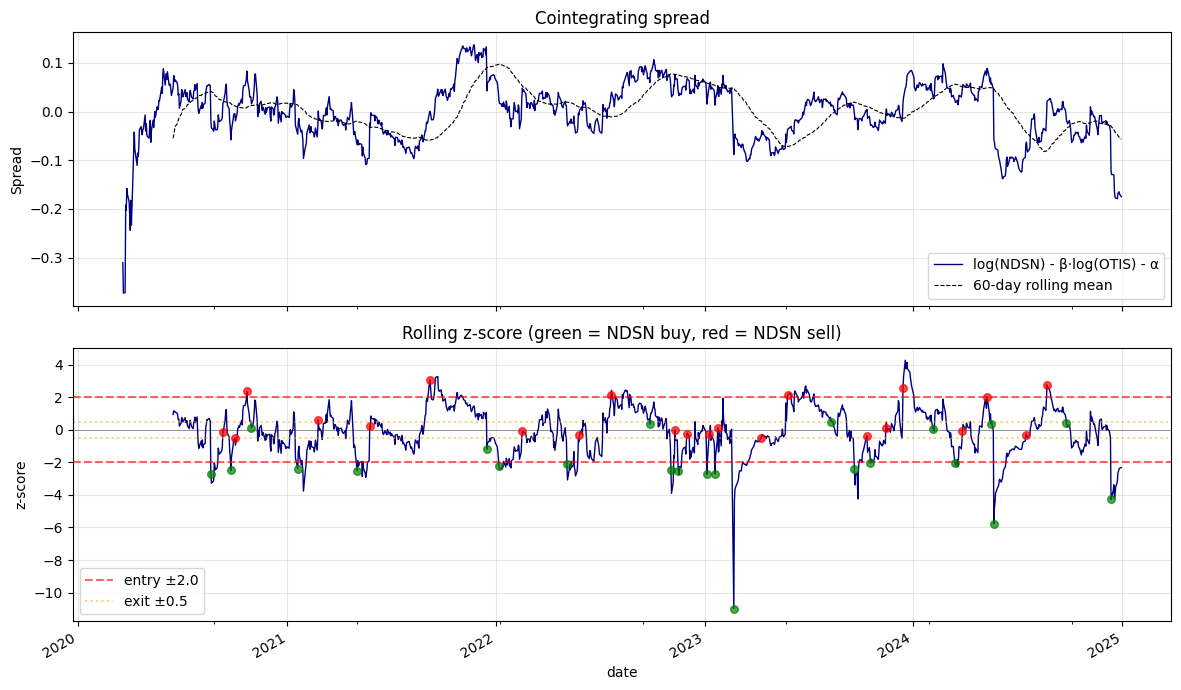

In [3]:
# Recompute the spread and z-score (matching the strategy logic)
HEDGE_RATIO = 0.649471
INTERCEPT = 2.572748
LOOKBACK = 60

aligned = wide[["NDSN", "OTIS"]].dropna()
spread = np.log(aligned["NDSN"]) - HEDGE_RATIO * np.log(aligned["OTIS"]) - INTERCEPT
mu = spread.shift(1).rolling(LOOKBACK).mean()
sigma = spread.shift(1).rolling(LOOKBACK).std()
z = (spread - mu) / sigma

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Spread
spread.plot(ax=axes[0], color="navy", linewidth=1.0, label="log(NDSN) - β·log(OTIS) - α")
mu.plot(ax=axes[0], color="black", linewidth=0.8, linestyle="--", label="60-day rolling mean")
axes[0].set_title("Cointegrating spread")
axes[0].set_ylabel("Spread")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Z-score with thresholds and trade markers
z.plot(ax=axes[1], color="navy", linewidth=1.0)
axes[1].axhline(2.0, color="red", linestyle="--", alpha=0.6, label="entry ±2.0")
axes[1].axhline(-2.0, color="red", linestyle="--", alpha=0.6)
axes[1].axhline(0.5, color="orange", linestyle=":", alpha=0.5, label="exit ±0.5")
axes[1].axhline(-0.5, color="orange", linestyle=":", alpha=0.5)
axes[1].axhline(0, color="black", linewidth=0.5, alpha=0.5)

# Mark each trade on the z-score plot
for _, trade in trades.iterrows():
    z_at_trade = z.loc[trade["timestamp"]] if trade["timestamp"] in z.index else np.nan
    if not np.isnan(z_at_trade):
        color = "green" if trade["quantity1"] > 0 else "red"
        axes[1].scatter(trade["timestamp"], z_at_trade, color=color, s=30, zorder=5, alpha=0.7)

axes[1].set_title("Rolling z-score (green = NDSN buy, red = NDSN sell)")
axes[1].set_ylabel("z-score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Compute per-trade P&L by pairing entries with exits
trades_chrono = trades.sort_values("timestamp").reset_index(drop=True)

# Each entry creates a position; the next trade closes it.
# Build round-trip P&L by walking through trades in pairs.
roundtrips = []
position = None
for _, t in trades_chrono.iterrows():
    if position is None:
        # Opening trade
        position = {
            "entry_time": t["timestamp"],
            "entry_q1": t["quantity1"],
            "entry_p1": t["fill_price1"],
            "entry_q2": t["quantity2"],
            "entry_p2": t["fill_price2"],
            "entry_commission": t["commission"],
            "entry_slippage": t["slippage_cost"],
        }
    else:
        # Closing trade
        # P&L = -(quantity_traded * exit_price - quantity_traded * entry_price)
        # Since we close with opposite quantity, this is straightforward.
        pnl1 = position["entry_q1"] * (t["fill_price1"] - position["entry_p1"])
        pnl2 = position["entry_q2"] * (t["fill_price2"] - position["entry_p2"])
        total_costs = position["entry_commission"] + position["entry_slippage"] + t["commission"] + t["slippage_cost"]
        net_pnl = pnl1 + pnl2 - position["entry_commission"] - t["commission"]
        roundtrips.append({
            "entry": position["entry_time"],
            "exit": t["timestamp"],
            "days_held": (t["timestamp"] - position["entry_time"]).days,
            "direction": "LONG" if position["entry_q1"] > 0 else "SHORT",
            "pnl1": pnl1,
            "pnl2": pnl2,
            "gross_pnl": pnl1 + pnl2,
            "costs": position["entry_commission"] + t["commission"],
            "net_pnl": net_pnl,
        })
        position = None

rt = pd.DataFrame(roundtrips)
print(f"Round-trips completed: {len(rt)}")
print()
print("Summary statistics:")
print(rt[["days_held", "gross_pnl", "costs", "net_pnl"]].describe().round(2))
print()
print(f"Win rate: {(rt['net_pnl'] > 0).mean()*100:.1f}%")
print(f"Average winner: ${rt[rt['net_pnl'] > 0]['net_pnl'].mean():.2f}")
print(f"Average loser:  ${rt[rt['net_pnl'] < 0]['net_pnl'].mean():.2f}")
print(f"Total gross PnL: ${rt['gross_pnl'].sum():.2f}")
print(f"Total costs:     ${rt['costs'].sum():.2f}")
print(f"Total net PnL:   ${rt['net_pnl'].sum():.2f}")
print()
print("First 10 round-trips:")
rt[["entry", "exit", "days_held", "direction", "gross_pnl", "net_pnl"]].head(10)

Round-trips completed: 22

Summary statistics:
       days_held  gross_pnl  costs  net_pnl
count      22.00      22.00  22.00    22.00
mean       31.45     207.51   0.77   206.74
std        26.08     354.54   0.09   354.51
min         4.00    -827.20   0.61  -827.97
25%         9.25      28.31   0.72    27.52
50%        22.00     258.34   0.76   257.63
75%        46.25     437.88   0.81   437.09
max       100.00     765.43   0.97   764.60

Win rate: 77.3%
Average winner: $351.06
Average loser:  $-283.92
Total gross PnL: $4565.31
Total costs:     $16.95
Total net PnL:   $4548.36

First 10 round-trips:


,entry,exit,days_held,direction,gross_pnl,net_pnl
0,2020-08-20,2020-09-10,21,LONG,95.593213,94.673265
1,2020-09-24,2020-10-01,7,LONG,554.182971,553.215111
2,2020-10-22,2020-10-30,8,SHORT,765.425964,764.595558
3,2021-01-19,2021-02-24,36,LONG,413.779195,412.855690
4,2021-05-03,2021-05-25,22,LONG,410.767166,409.930001
5,2021-09-07,2021-12-16,100,SHORT,-315.206400,-315.921315
6,2022-01-06,2022-02-16,41,LONG,-82.358726,-83.080630
7,2022-05-05,2022-05-27,22,LONG,252.712160,251.900624
8,2022-07-21,2022-09-27,68,SHORT,200.912727,200.128030
9,2022-11-03,2022-11-10,7,LONG,613.142041,612.351749
